# Metamorphosis series solver -- test notebook

End-to-end walkthrough of `MetamorphosisSeries`/`MetamorphosisSeriesVisualizer`
(`src/MetamorphosisSeries.py`, `src/SeriesVisualizer.py`), the generalization
of the single-pair solver (see `04_test_solver.ipynb`) to a whole
longitudinal series `I_1..I_{N+1}`. The energy minimized is

```
sum_{n=1}^{N} E_n(v^n, z^n)
```

i.e. the sum of N per-leg book-formula (13.13) energies, one per
consecutive pair ("leg" n: `I_n -> I_{n+1}`). Since the energy has no term
coupling different legs, this is exactly equivalent to running the
existing single-pair `Metamorphosis.fit` once per leg -- `MetamorphosisSeries`
is a pure orchestration/stitching layer, not a new numerical scheme (see
`README.md`'s "Whole series" section).

Uses the full `BDD_AMD_062026/031_FA_C_OD` series (22 frames, 21 legs) with
masks, on a fast/coarse config so the notebook runs in a couple of minutes --
extend `pyramid_scales`/`level_iters` for a production run (see
`04_test_solver.ipynb`'s `seg_demo_kwargs` for a slower, full-resolution
example). The final section exports everything into `notebook_outputs_series/`.

In [9]:
import os
import sys
sys.path.insert(0, "src")
import glob

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

%matplotlib inline

SERIES_DIR = "tests/fixtures/065_LE_A_OD"

## 1. Build the frame/mask lists

`preprocessed/` and `segmentations/` filenames do **not** share a numbering
scheme in this dataset (e.g. `UTF-8FAC20013.png` corresponds to
`frame_0009.png`, not frame 13) -- frames correspond by *position* in each
directory's sorted listing, not by matching numeric suffix. `preprocessed/`
also contains stray `*_processed.png` duplicates at a different resolution
that must be excluded from the glob.

In [10]:
image_paths = sorted(glob.glob(f"{SERIES_DIR}/images/*.png"))
mask_paths = sorted(glob.glob(f"{SERIES_DIR}/segmentations/*.png"))

assert len(image_paths) == len(mask_paths), \
    f"{len(image_paths)} images vs {len(mask_paths)} masks -- expected one mask per frame"
print(f"{len(image_paths)} frames -> {len(image_paths) - 1} legs")
for i, (a, s) in enumerate(zip(image_paths, mask_paths)):
    print(f"  frame {i:2d}: {os.path.basename(a):24s}  mask: {os.path.basename(s)}")

3 frames -> 2 legs
  frame  0: frame_00.png              mask: frame_00.png
  frame  1: frame_04.png              mask: frame_04.png
  frame  2: frame_08.png              mask: frame_08.png


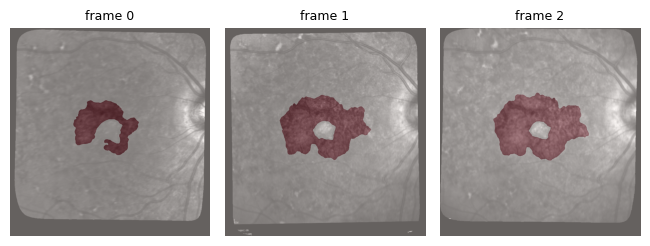

In [11]:
from core.Image import Image

n_preview = min(6, len(image_paths))
preview_idx = np.linspace(0, len(image_paths) - 1, n_preview).round().astype(int)

fig, axes = plt.subplots(1, n_preview, figsize=(2.2 * n_preview, 2.6))
for ax, i in zip(axes, preview_idx):
    img = Image(image_paths[i])
    mask = Image(mask_paths[i])
    ax.imshow(img.array, cmap="gray", vmin=0, vmax=1)
    ax.imshow(mask.array, cmap="Reds", alpha=0.4)
    ax.set_title(f"frame {i}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Fit the series

`MetamorphosisSeries.fit` chains `Metamorphosis.fit` across every consecutive
pair, printing a header per leg. Same `solver_kwargs` as the single-pair
solver, applied identically to every leg.

In [12]:
from forward.MetamorphosisSeries import MetamorphosisSeries

series_kwargs = dict(
    T=4, lambda_data=200.0, lambda_seg=500.0,
    pyramid_scales=(1/8,1/4,1), level_iters=(200,150,10), level_lrs=(0.05, 0.02),
    device="cpu",
)
series = MetamorphosisSeries.fit(image_paths, mask_paths, verbose=False, **series_kwargs)
print(f"fitted {len(series.legs)} legs")

fitted 2 legs


## 3. Inspect and visualize the stitched series

`MetamorphosisSeriesVisualizer` wraps the series as a single stitched
`Metamorphosis` (`MetamorphosisSeries.as_metamorphosis()`), so every existing
`MetamorphosisVisualizer` plot works unchanged across the whole chain. It
adds two series-only views: one panel per *original* frame (rather than per
solver substep), and a per-leg energy breakdown.

In [13]:
from forward.SeriesVisualizer import MetamorphosisSeriesVisualizer

viz = MetamorphosisSeriesVisualizer(series)
print(viz.summary())

Metamorphosis series summary
2 legs, 3 frames
first frame: tests/fixtures/065_LE_A_OD/images/frame_00.png
last frame:  tests/fixtures/065_LE_A_OD/images/frame_08.png

Total energy (sum over all legs, the quantity the series minimizes):
  loss       = 2,052,702.6250
  E_kinetic  = 1,025,498.9844
  E_data     = 186.6465
  E_seg      = 53.7419

Metamorphosis summary
a(0): tests/fixtures/065_LE_A_OD/images/frame_00.png
a(1): tests/fixtures/065_LE_A_OD/images/frame_08.png
resolution solved at: 211x203, T=8 steps
  NB: input images are 843x811 natively -- pyramid_scales=[0.125, 0.25, 1] stopped short of 1.0, so this run (and every figure/frame below) is at 211x203, not native resolution.
lambda_data=200.0  lambda_seg=500.0  kernel_sigma_frac=0.03

Final energy (finest level):
  loss         = 532,278.38
  E_kinetic    = 127,187.42
  E_data       = 96.8919  (rms 0.01682, ~4.29/255 gray levels)
  E_seg        = 11.8796  (rms 0.00589)

Geometric deformation vs. residual:
  deformation (v):  88.

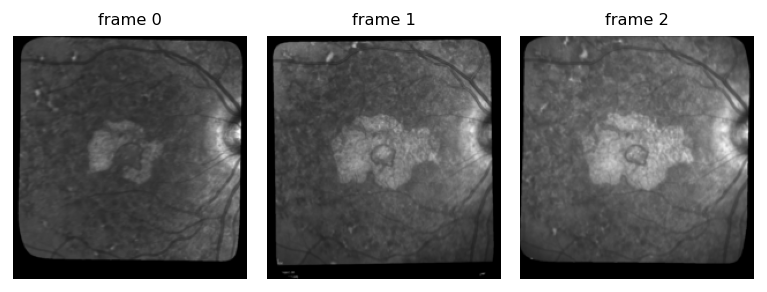

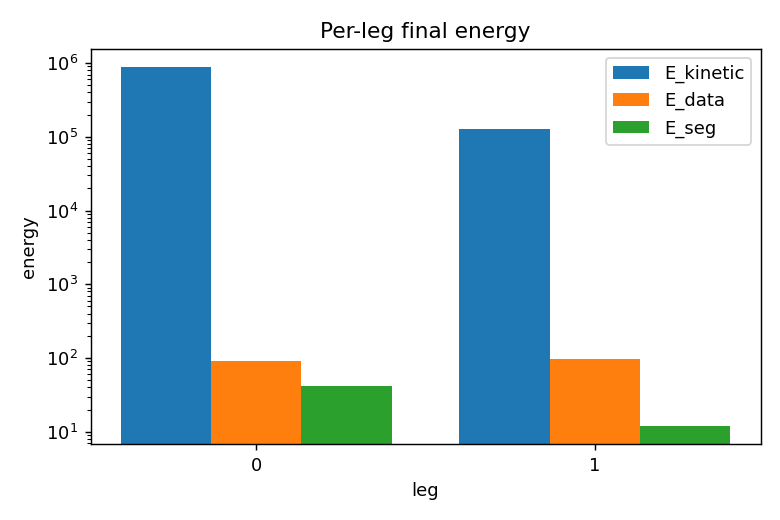

In [14]:
os.makedirs("notebook_outputs_series", exist_ok=True)

viz.plot_input_frame_strip("notebook_outputs_series/fig_input_frames.png")
display(IPImage("notebook_outputs_series/fig_input_frames.png"))

viz.plot_per_leg_energy("notebook_outputs_series/fig_per_leg_energy.png")
display(IPImage("notebook_outputs_series/fig_per_leg_energy.png"))

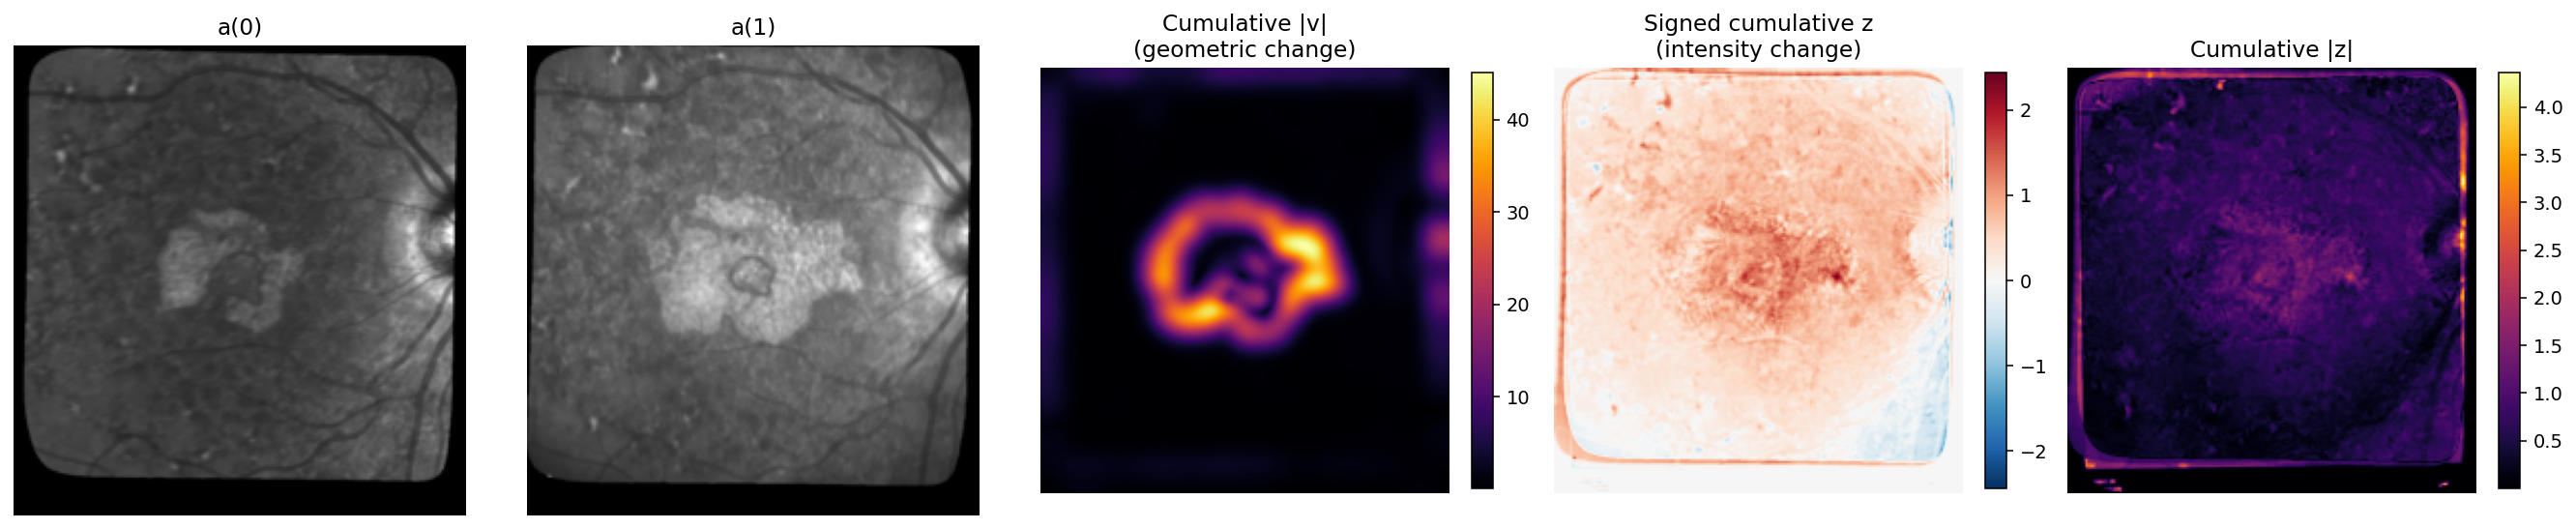

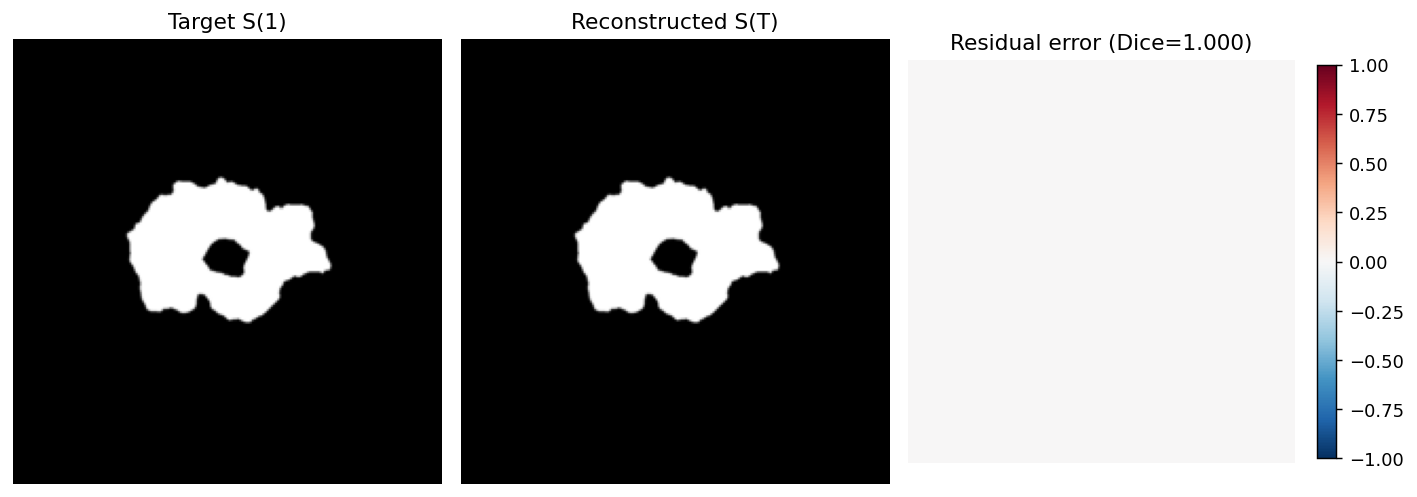

In [15]:
viz.viz.plot_deformation_vs_residual("notebook_outputs_series/fig_v_vs_z.png")
display(IPImage("notebook_outputs_series/fig_v_vs_z.png"))

viz.viz.plot_matching_segmentation("notebook_outputs_series/fig_matching_segmentation.png")
display(IPImage("notebook_outputs_series/fig_matching_segmentation.png"))

## 4. Save, export, and reload

`series.save()` writes one subdir (`leg_000/`, `leg_001/`, ...) per leg plus
a `meta.json`; `viz.export_all()` writes the series-level figures above plus
every per-leg `MetamorphosisVisualizer` figure (trajectory strip, loss
history, velocity/displacement fields, frame sequences, ...). `.load()`
reconstructs the series from disk without re-solving.

In [16]:
series.save("notebook_outputs_series/series_fit")
viz.export_all("notebook_outputs_series")
print("Saved series run to notebook_outputs_series/")

reloaded = MetamorphosisSeries.load("notebook_outputs_series/series_fit")
assert len(reloaded.legs) == len(series.legs)
assert reloaded.full_a_traj().shape == series.full_a_traj().shape
print("Reload sanity check passed -- full_a_traj shape:", reloaded.full_a_traj().shape)

Saved series run to notebook_outputs_series/
Reload sanity check passed -- full_a_traj shape: (9, 211, 203)
